<a href="https://colab.research.google.com/github/Muqqadas30/fsdl-my-labs/blob/main/lab02/lab02b_cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pytorch-lightning --quiet

import torch
import torch.nn as nn
import torch.nn.functional as F
import pytorch_lightning as pl
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets
import matplotlib.pyplot as plt

version = pl.__version__
print("PyTorch Lightning version:", version)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.4/852.4 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 48.3 MB/s eta 0:00:00
PyTorch Lightning version: 2.6.5


In [2]:
train_raw = datasets.FashionMNIST(root="./data", train=True, download=True)
valid_raw = datasets.FashionMNIST(root="./data", train=False, download=True)

# Shape: (N, 1, 28, 28) -- channel dimension add kiya (1 = grayscale)
x_train = train_raw.data.float().unsqueeze(1) / 255.0
y_train = train_raw.targets

x_valid = valid_raw.data.float().unsqueeze(1) / 255.0
y_valid = valid_raw.targets

class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

print("x_train shape:", x_train.shape)   # (60000, 1, 28, 28)

100%|██████████| 26.4M/26.4M [00:01<00:00, 18.3MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 278kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.04MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 26.9MB/s]


x_train shape: torch.Size([60000, 1, 28, 28])


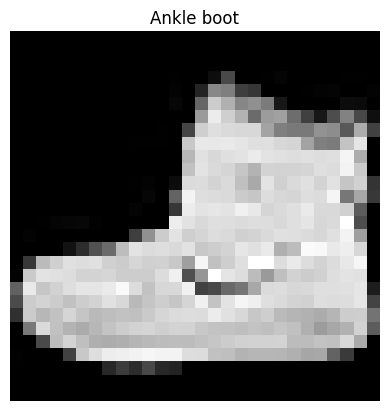

In [3]:
idx = 0
plt.imshow(x_train[idx][0], cmap="gray")
plt.title(class_names[y_train[idx].item()])
plt.axis("off")
plt.show()

In [4]:
class FashionDataset(Dataset):
    def __init__(self, x, y):
        self.x = x
        self.y = y

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

train_ds = FashionDataset(x_train, y_train)
valid_ds = FashionDataset(x_valid, y_valid)

In [5]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        # Conv Block 1: 1 input channel -> 16 output channels (feature maps)
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1)
        # padding=1 rakha hai taake shape same rahe (28x28 se 28x28)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        # pooling se image size aadhi ho jati hai (28x28 -> 14x14)

        # Conv Block 2: 16 -> 32 channels
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        # dobara pooling: 14x14 -> 7x7

        # Final classification MLP
        self.fc1 = nn.Linear(32 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        # x shape: (batch, 1, 28, 28)
        x = self.conv1(x)          # (batch, 16, 28, 28)
        x = F.relu(x)
        x = self.pool(x)           # (batch, 16, 14, 14)

        x = self.conv2(x)          # (batch, 32, 14, 14)
        x = F.relu(x)
        x = self.pool(x)           # (batch, 32, 7, 7)

        x = torch.flatten(x, 1)    # (batch, 32*7*7) -- ab MLP ke liye flatten karte hain
        x = self.fc1(x)
        x = F.relu(x)
        x = self.fc2(x)            # (batch, 10)
        return x

cnn = SimpleCNN()
print(cnn)

SimpleCNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=1568, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


In [6]:
total_params = sum(p.numel() for p in cnn.parameters())
print(f"Total parameters: {total_params:,}")

# Har layer ka size dekhna
for name, p in cnn.named_parameters():
    print(f"{name}: {p.numel():,} parameters")

Total parameters: 206,922
conv1.weight: 144 parameters
conv1.bias: 16 parameters
conv2.weight: 4,608 parameters
conv2.bias: 32 parameters
fc1.weight: 200,704 parameters
fc1.bias: 128 parameters
fc2.weight: 1,280 parameters
fc2.bias: 10 parameters


In [7]:
sample = x_train[0:1]
output = cnn(sample)
print("Output shape:", output.shape)   # (1, 10)
print("Predicted class:", class_names[torch.argmax(output).item()])
print("Actual class:", class_names[y_train[0].item()])

Output shape: torch.Size([1, 10])
Predicted class: T-shirt/top
Actual class: Ankle boot


In [8]:
class FashionCNN(pl.LightningModule):
    def __init__(self):
        super().__init__()
        self.model = SimpleCNN()

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = F.cross_entropy(logits, y)
        acc = (torch.argmax(logits, dim=1) == y).float().mean()

        self.log("train_loss", loss, prog_bar=True)
        self.log("train_acc", acc, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = F.cross_entropy(logits, y)
        acc = (torch.argmax(logits, dim=1) == y).float().mean()

        self.log("val_loss", loss, prog_bar=True)
        self.log("val_acc", acc, prog_bar=True)
        return loss

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=1e-3)

In [9]:
train_dataloader = DataLoader(train_ds, batch_size=64, shuffle=True)
valid_dataloader = DataLoader(valid_ds, batch_size=128)

In [10]:
model = FashionCNN()

trainer = pl.Trainer(max_epochs=3, accelerator="auto")
trainer.fit(model, train_dataloaders=train_dataloader, val_dataloaders=valid_dataloader)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


┏━━━┳━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type      ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model │ SimpleCNN │  206 K │ train │     0 │
└───┴───────┴───────────┴────────┴───────┴───────┘

Trainable params: 206 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 206 K                                                                                                
Total estimated model params size (MB): 0.828                                                                      
Modules in train mode: 6                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=3` reached.


In [11]:
trainer.validate(model, dataloaders=valid_dataloader)

Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│          val_acc          │    0.8937000036239624     │
│         val_loss          │    0.29267364740371704    │
└───────────────────────────┴───────────────────────────┘

[{'val_loss': 0.29267364740371704, 'val_acc': 0.8937000036239624}]

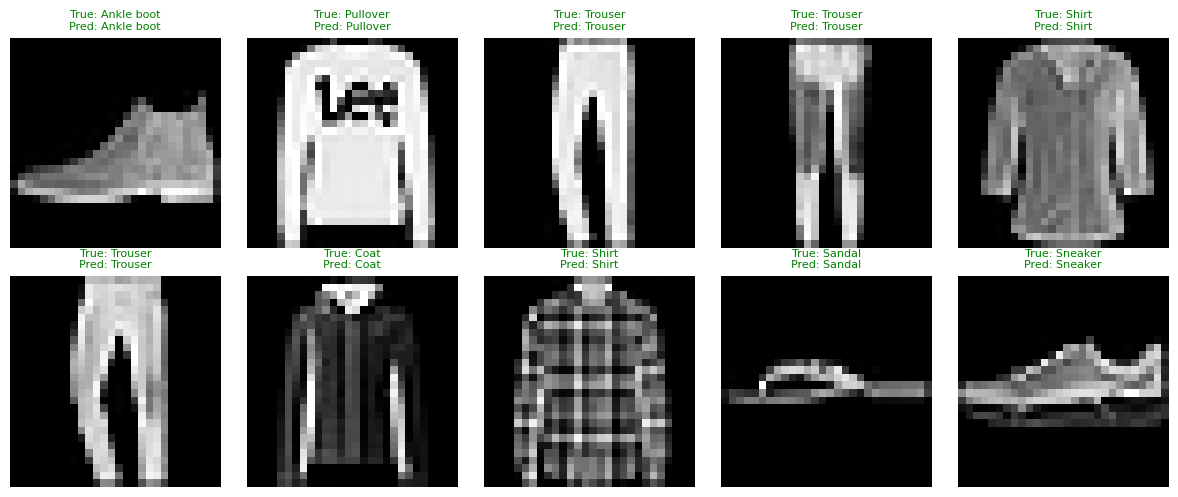

In [12]:
model.eval()
sample_images, sample_labels = next(iter(valid_dataloader))

with torch.no_grad():
    outputs = model(sample_images)
    preds = torch.argmax(outputs, dim=1)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    img = sample_images[i][0]
    true_label = class_names[sample_labels[i].item()]
    pred_label = class_names[preds[i].item()]
    color = "green" if true_label == pred_label else "red"

    ax.imshow(img, cmap="gray")
    ax.set_title(f"True: {true_label}\nPred: {pred_label}", color=color, fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.show()